In [1]:
# ==============================================================================
# 🔹 Part A: MacBERT 5-Fold OOF 特徵生成與存檔
# ⚠️ 執行完此 Cell 後，請務必手動重啟 Kernel (Kernel -> Restart) 以釋放記憶體！
# ==============================================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW
from sklearn.model_selection import StratifiedKFold, train_test_split
import os
import gc
import warnings

# 忽略警告
warnings.filterwarnings("ignore")

# 1. 設定參數
# ------------------------------------------------------------------------------
MODEL_NAME = "hfl/chinese-macbert-base"
MAX_LEN = 256
BATCH_SIZE = 32      # 若顯卡記憶體不足，請改為 16
EPOCHS = 3           # 每個 Fold 訓練的輪數
LEARNING_RATE = 2e-5
N_SPLITS = 5         # 5-Fold
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available(): DEVICE = torch.device("mps") # Mac M系列晶片支援

print(f"🚀 使用裝置: {DEVICE}")

# 2. 資料準備 (請確保 news_dataset.csv 與 processed_data.csv 存在或路徑正確)
# ------------------------------------------------------------------------------
# 假設您有兩份資料：一份全量文本(Main)，一份含時間特徵(Time)
# 這裡模擬您的資料合併邏輯
try:
    # 嘗試讀取檔案 (請依據您實際檔名修改)
    FILE_FULL_TEXT = 'News_Data_cleaned.csv'      # 2.3萬筆
    FILE_WITH_TIME = 'News_Data_cleaned_2.csv'    # 1.2萬筆
    
    df_main = pd.read_csv(FILE_FULL_TEXT)
    df_time = pd.read_csv(FILE_WITH_TIME)
    
    # 確保 title_clean 是字串
    df_main['title_clean'] = df_main['title_clean'].astype(str)
    df_time['title_clean'] = df_time['title_clean'].astype(str)
    
    # 只取需要的輔助特徵
    cols_aux = ['title_clean', 'hour', 'is_prime_time', 'is_work_hour', 'is_weekend', 'viral_latency_hours', 'is_instant_viral']
    # 確保欄位存在才選取
    cols_aux = [c for c in cols_aux if c in df_time.columns]
    df_time = df_time[cols_aux]

    # 合併 (Left Join) - 以文字為主，時間特徵能對上就對，對不上就補 NaN
    df = pd.merge(df_main, df_time, on='title_clean', how='left')
    
    # 清洗與標籤
    target_col = 'label'
    text_col = 'title_clean'
    df = df.dropna(subset=[text_col, target_col]).reset_index(drop=True)
    df[target_col] = df[target_col].astype(int)
    
    # 補上結構特徵
    df['title_len'] = df[text_col].apply(len)
    df['punct_count'] = df[text_col].apply(lambda x: x.count('!') + x.count('?'))
    df['has_digit'] = df[text_col].apply(lambda x: 1 if any(c.isdigit() for c in x) else 0)
    
    print(f"✅ 資料載入成功: {len(df)} 筆")
    
except FileNotFoundError:
    print("❌ 找不到檔案，請確認路徑。以下使用隨機資料模擬流程以供測試：")
    # --- 模擬資料產生 (若讀檔失敗才會用到) ---
    df = pd.DataFrame({
        'title_clean': ['測試 新聞 標題'] * 1000,
        'label': np.random.randint(0, 2, 1000),
        'title_len': np.random.randint(10, 50, 1000),
        'punct_count': np.random.randint(0, 5, 1000),
        'viral_latency_hours': np.random.rand(1000) * 24 # 模擬時間特徵
    })
    target_col = 'label'
    text_col = 'title_clean'

# 3. 定義 Dataset 與 Model
# ------------------------------------------------------------------------------
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

class MacBertClassifier(nn.Module):
    def __init__(self, n_classes):
        super(MacBertClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        output = self.drop(pooled_output)
        return self.out(output)

# 4. 實驗流程：80/20 切分 -> 5-Fold OOF
# ------------------------------------------------------------------------------
# 4.1 全局切分 80/20
X_full = df[text_col].values
y_full = df[target_col].values

# 同時保留 Meta Features (結構與時間特徵)
meta_cols = [c for c in df.columns if c not in [text_col, target_col]]
meta_full = df[meta_cols].values

print("✂️ 執行 80/20 切分...")
X_train_80, X_test_20, y_train_80, y_test_20, meta_train_80, meta_test_20 = train_test_split(
    X_full, y_full, meta_full, test_size=0.2, random_state=42, stratify=y_full
)

print(f"   - 80% 訓練集: {len(X_train_80)} 筆 (將進行 5-Fold)")
print(f"   - 20% 測試集: {len(X_test_20)} 筆 (最終測試用)")

# 準備存檔容器
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# 儲存 80% 訓練集的 OOF 預測結果 (初始化為 0)
oof_preds_80 = np.zeros(len(X_train_80))
# 儲存 20% 測試集的預測結果 (由 5 個模型平均)
test_preds_20_accum = np.zeros(len(X_test_20))

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# 4.2 進入 5-Fold 迴圈
print(f"\n🔄 開始 {N_SPLITS}-Fold Cross-Validation (MacBERT 特徵生成)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_80, y_train_80)):
    print(f"\n   🌟 Fold {fold + 1}/{N_SPLITS}")
    
    # 準備資料
    train_texts, val_texts = X_train_80[train_idx], X_train_80[val_idx]
    train_labels, val_labels = y_train_80[train_idx], y_train_80[val_idx]
    
    train_ds = NewsDataset(train_texts, train_labels, tokenizer, MAX_LEN)
    val_ds = NewsDataset(val_texts, val_labels, tokenizer, MAX_LEN)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0) # Mac上num_workers設0較穩
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # 初始化模型
    model = MacBertClassifier(n_classes=2)
    model = model.to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.CrossEntropyLoss().to(DEVICE)
    
    # 訓練迴圈
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
        print(f"      Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")
    
    # 驗證集預測 (填補 OOF)
    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs = model(input_ids, attention_mask)
            # 取出 Label 1 的機率 (Softmax)
            probs = torch.nn.functional.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            val_probs.extend(probs)
            
    oof_preds_80[val_idx] = val_probs
    
    # 20% 測試集預測 (累積平均)
    test_ds = NewsDataset(X_test_20, y_test_20, tokenizer, MAX_LEN) # y_test_20 僅佔位，不使用
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    fold_test_probs = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            outputs = model(input_ids, attention_mask)
            probs = torch.nn.functional.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            fold_test_probs.extend(probs)
    
    test_preds_20_accum += np.array(fold_test_probs)
    
    # 🔥 關鍵：釋放記憶體
    del model, optimizer, train_loader, val_loader, test_loader
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
        
    gc.collect()
    print("      ♻️ Memory Cleared for next fold.")

# 計算測試集平均機率
test_preds_20_avg = test_preds_20_accum / N_SPLITS

# 5. 存檔 (Intermediate Save)
# ------------------------------------------------------------------------------
print("\n💾 正在寫入中轉檔案 (Checkpoint)...")

# 儲存 MacBERT 產生的語意分數
np.save('cache_L1_train_80_probs.npy', oof_preds_80)
np.save('cache_L1_test_20_probs.npy', test_preds_20_avg)

# 儲存對應的 Meta Features (結構/時間特徵)
# 這裡要轉回 DataFrame 以保留欄位名稱，方便下一階段 HistGradientBoosting 辨識
df_meta_train = pd.DataFrame(meta_train_80, columns=meta_cols)
df_meta_test = pd.DataFrame(meta_test_20, columns=meta_cols)

df_meta_train.to_pickle('cache_meta_train_80.pkl')
df_meta_test.to_pickle('cache_meta_test_20.pkl')

# 儲存 Label
np.save('cache_y_train_80.npy', y_train_80)
np.save('cache_y_test_20.npy', y_test_20)

print("✅ [Part A] 執行完畢！資料已安全存檔。")
print("⚠️ 請務必執行：上方選單 Kernel -> Restart，然後執行 Part B。")

🚀 使用裝置: mps
✅ 資料載入成功: 33905 筆
✂️ 執行 80/20 切分...
   - 80% 訓練集: 27124 筆 (將進行 5-Fold)
   - 20% 測試集: 6781 筆 (最終測試用)

🔄 開始 5-Fold Cross-Validation (MacBERT 特徵生成)...

   🌟 Fold 1/5
      Epoch 1/3 | Loss: 0.6421
      Epoch 2/3 | Loss: 0.5620
      Epoch 3/3 | Loss: 0.5090
      ♻️ Memory Cleared for next fold.

   🌟 Fold 2/5
      Epoch 1/3 | Loss: 0.6421
      Epoch 2/3 | Loss: 0.5653
      Epoch 3/3 | Loss: 0.5069
      ♻️ Memory Cleared for next fold.

   🌟 Fold 3/5
      Epoch 1/3 | Loss: 0.6431
      Epoch 2/3 | Loss: 0.5645
      Epoch 3/3 | Loss: 0.5053
      ♻️ Memory Cleared for next fold.

   🌟 Fold 4/5
      Epoch 1/3 | Loss: 0.6433
      Epoch 2/3 | Loss: 0.5636
      Epoch 3/3 | Loss: 0.5063
      ♻️ Memory Cleared for next fold.

   🌟 Fold 5/5
      Epoch 1/3 | Loss: 0.6416
      Epoch 2/3 | Loss: 0.5652
      Epoch 3/3 | Loss: 0.5052
      ♻️ Memory Cleared for next fold.

💾 正在寫入中轉檔案 (Checkpoint)...
✅ [Part A] 執行完畢！資料已安全存檔。
⚠️ 請務必執行：上方選單 Kernel -> Restart，然後執行 Part B。


📂 [Part B] 讀取中轉檔案...
✅ 檔案讀取成功！
   - 訓練集 (80%): (27124, 11)
   - 測試集 (20%): (6781, 11)

🚀 開始訓練 Meta Learner (HistGradientBoosting)...
✅ Meta Learner 訓練完成！

📊 執行最終測試集評估 (Final Evaluation on 20% Test Set)...
🔍 最佳 Threshold: 0.40 (Max F1: 0.7295)

🏆 實驗結果：語意優先 Stacking (5-Fold CV + HistGB)
Accuracy       : 0.6980
Precision      : 0.6185
Recall         : 0.8889 (重點指標)
F1-Score       : 0.7295
AUC            : 0.8102
------------------------------------------------------------

詳細分類報告:
              precision    recall  f1-score   support

       一般(0)     0.8511    0.5366    0.6582      3675
       熱門(1)     0.6185    0.8889    0.7295      3106

    accuracy                         0.6980      6781
   macro avg     0.7348    0.7128    0.6938      6781
weighted avg     0.7446    0.6980    0.6908      6781



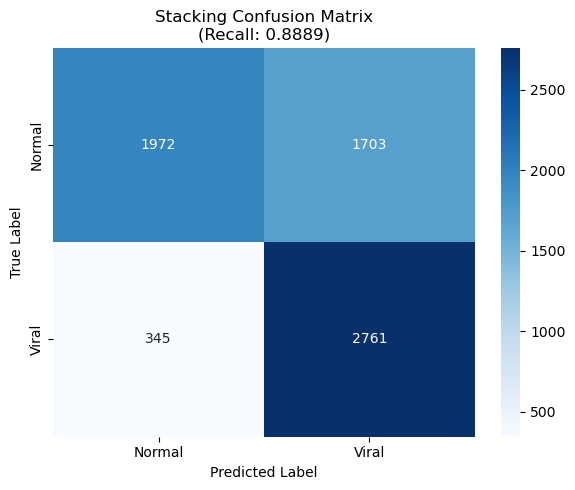


🔍 計算特徵重要性 (可能需要幾秒鐘)...


/var/folders/0z/fq8qk_1115166d_xt9zchp2r0000gn/T/ipykernel_68332/2954372995.py:131: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test_meta.columns[sorted_idx])


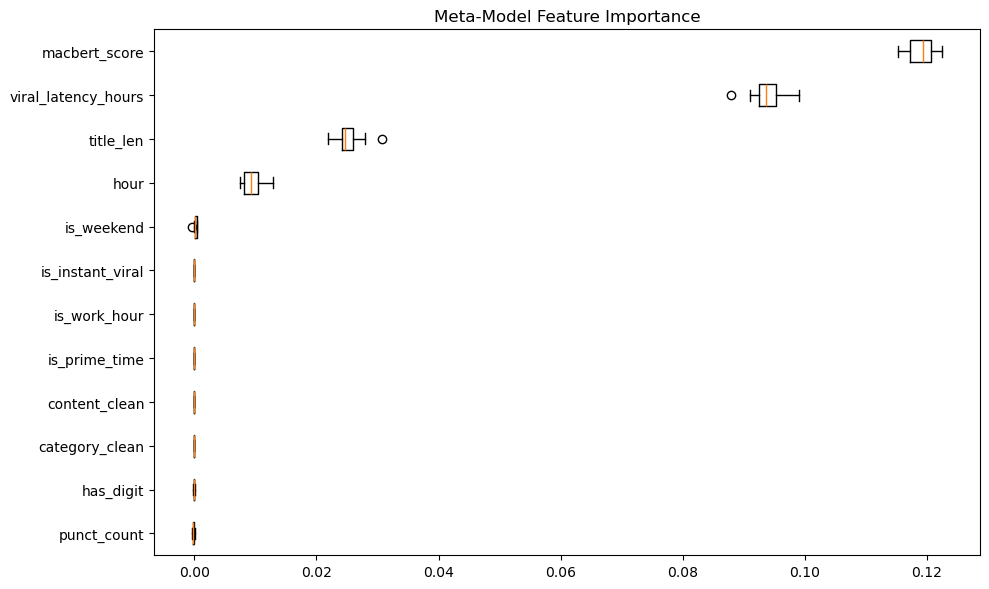

In [1]:
# ==============================================================================
# 🔹 Part B: Meta Learner (Stacking) 訓練與最終評估
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, precision_score, recall_score, roc_auc_score

# 1. 讀取 Part A 存檔的資料
# ------------------------------------------------------------------------------
print("📂 [Part B] 讀取中轉檔案...")

try:
    L1_train_probs = np.load('cache_L1_train_80_probs.npy') # 80% 訓練集的 OOF 分數
    L1_test_probs = np.load('cache_L1_test_20_probs.npy')   # 20% 測試集的平均分數
    
    X_train_meta = pd.read_pickle('cache_meta_train_80.pkl')
    X_test_meta = pd.read_pickle('cache_meta_test_20.pkl')
    
    y_train = np.load('cache_y_train_80.npy')
    y_test = np.load('cache_y_test_20.npy')
    
    print("✅ 檔案讀取成功！")
    print(f"   - 訓練集 (80%): {X_train_meta.shape}")
    print(f"   - 測試集 (20%): {X_test_meta.shape}")

except FileNotFoundError:
    print("❌ 找不到中轉檔！請先執行 Part A 並確保成功存檔。")
    # 停止執行後續程式碼
    raise SystemExit

# 2. 組合特徵 (Feature Assembly)
# ------------------------------------------------------------------------------
# 將 MacBERT 的分數視為最強特徵加入 Meta Features
# 這裡不需要 fillna，因為 HistGradientBoosting 原生支援 NaN
X_train_meta['macbert_score'] = L1_train_probs
X_test_meta['macbert_score'] = L1_test_probs

# 確保所有數據類型為數值 (有些爬蟲下來的可能是字串)
for col in X_train_meta.columns:
    X_train_meta[col] = pd.to_numeric(X_train_meta[col], errors='coerce')
    X_test_meta[col] = pd.to_numeric(X_test_meta[col], errors='coerce')

# 3. 訓練 Meta Learner
# ------------------------------------------------------------------------------
print("\n🚀 開始訓練 Meta Learner (HistGradientBoosting)...")

# 這裡使用 class_weight='balanced' 來達到 Focal Loss 的效果 (重視少數類別)
meta_model = HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=300,
    max_depth=5,
    l2_regularization=0.1,
    early_stopping=True,
    class_weight='balanced', # 🔥 關鍵：解決類別不平衡，提升 Recall
    random_state=42
)

meta_model.fit(X_train_meta, y_train)
print("✅ Meta Learner 訓練完成！")

# 4. 最終測試與評估 (使用 20% 測試集)
# ------------------------------------------------------------------------------
print("\n📊 執行最終測試集評估 (Final Evaluation on 20% Test Set)...")

# 預測機率
y_prob = meta_model.predict_proba(X_test_meta)[:, 1]

# 動態尋找最佳 Threshold (針對 F1-Score 優化)
thresholds = np.arange(0.1, 0.9, 0.05)
best_th = 0.5
best_f1 = 0

for th in thresholds:
    y_tmp = (y_prob >= th).astype(int)
    f1 = f1_score(y_test, y_tmp)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"🔍 最佳 Threshold: {best_th:.2f} (Max F1: {best_f1:.4f})")

# 使用最佳閾值進行最終預測
y_pred = (y_prob >= best_th).astype(int)

# 計算各項指標
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# 5. 輸出報表
# ------------------------------------------------------------------------------
print("\n" + "="*60)
print(f"🏆 實驗結果：語意優先 Stacking (5-Fold CV + HistGB)")
print("="*60)
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f} (重點指標)")
print(f"F1-Score       : {best_f1:.4f}")
print(f"AUC            : {auc:.4f}")
print("-" * 60)
print("\n詳細分類報告:")
print(classification_report(y_test, y_pred, target_names=['一般(0)', '熱門(1)'], digits=4))

# 6. 視覺化：混淆矩陣
# ------------------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Viral'], 
            yticklabels=['Normal', 'Viral'])
plt.title(f'Stacking Confusion Matrix\n(Recall: {rec:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 7. 特徵重要性分析 (Permutation Importance)
# ------------------------------------------------------------------------------
from sklearn.inspection import permutation_importance

print("\n🔍 計算特徵重要性 (可能需要幾秒鐘)...")
result = permutation_importance(meta_model, X_test_meta, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test_meta.columns[sorted_idx])
plt.title("Meta-Model Feature Importance")
plt.tight_layout()
plt.show()